<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/bowtie_lopa_sif_risk_analysis.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

# Bow-tie, LOPA, and safety-instrumented risk analysis with NeqSim

**Audience.** Process, safety, reliability, and automation engineers who can read a
steady-state flowsheet and need a reproducible screening workflow from process evidence to
barrier decisions.

**Prerequisites.** Basic Python, absolute pressure, phase separation, and the distinction
between a hazard, a top event, and a consequence. No local files or proprietary data are
required.

## Learning objectives

By the end you will be able to:

1. build and validate an SRK inlet-cooling and separation process;
2. let NeqSim discover an overpressure bow-tie from process topology;
3. configure and verify a `SafetyInstrumentedFunction` (SIF);
4. construct a layer of protection analysis (LOPA) with explicit frequencies and PFDs;
5. study proof-test interval and architecture effects; and
6. turn process and risk outputs into a reusable screening decision.

## Scope, assumptions, and units

The example represents a high-pressure natural-gas inlet cooler and two-phase separator.
Pressures are absolute (`bara`), temperatures are in $^\circ$C, mass rates are in kg/h,
failure rates are per hour, and event frequencies are per year.

The composition and reliability inputs are deterministic educational values. They are not
plant failure data, a HAZOP record, a safety-requirements specification, or certification
evidence. Independence between credited layers is an explicit screening assumption.

## Theory: protection layers

For independent protection layers, the mitigated event frequency is

$$
f_{\mathrm{mit}} = f_{\mathrm{init}}\prod_{i=1}^{n} PFD_i
$$

where $f_{\mathrm{init}}$ is the initiating-event frequency in yr$^{-1}$ and $PFD_i$ is
the dimensionless probability that layer $i$ fails on demand. The total risk-reduction
factor is

$$
RRF_{\mathrm{total}} = \frac{f_{\mathrm{init}}}{f_{\mathrm{mit}}}
$$

This multiplication is valid only when the layers are effective for the scenario,
auditable, and sufficiently independent.

## Theory: simplified SIF PFD

For a low-demand one-out-of-one architecture with a constant dangerous-undetected failure
rate $\lambda_{DU}$ and proof-test interval $T$, the usual first-order screening estimate is

$$
PFD_{\mathrm{avg,1oo1}} = \frac{\lambda_{DU}T}{2}
$$

NeqSim also provides screening calculations for 1oo2 and 2oo3 voting. They are useful for
teaching architecture and test-interval effects, but a project verification must include
sensors, logic solver, final elements, diagnostics, common-cause failure, proof-test
coverage, repair, bypasses, and systematic capability.

## Install NeqSim from PyPI

Google Colab starts without NeqSim. This cell installs the current public package only when
the runtime does not already provide it. A runtime restart is not required.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

## Imports and runtime evidence

NeqSim's Python package starts the released Java library through JPype. We record the
package, Python, and Java versions so a saved result can be traced to its runtime.

In [2]:
import json
import os
import platform
import subprocess

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-config")

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import SVG, display
from importlib.metadata import version
from matplotlib.colors import ListedColormap
from neqsim import jneqsim


runtime = {
    "neqsim": version("neqsim"),
    "python": platform.python_version(),
    "java": subprocess.check_output(
        ["java", "-version"],
        stderr=subprocess.STDOUT,
        text=True,
    ).splitlines()[0],
}
display(pd.DataFrame([runtime]))

,neqsim,python,java
0,3.16.0,3.12.13,"openjdk version ""17.0.19"" 2026-04-21"


## Define the engineering case

The SRK equation of state is appropriate for a hydrocarbon-rich screening fluid. Classical
mixing is sufficient because the example contains no strongly associating component.
Multiphase checking is enabled so condensed liquid can form after cooling.

In [3]:
CASE = {
    "feed_temperature_C": 25.0,
    "feed_pressure_bara": 70.0,
    "feed_flow_kg_per_hr": 15_000.0,
    "cooler_outlet_temperature_C": 5.0,
    "separator_volume_m3": 20.0,
    "separator_mawp_bara": 95.0,
    "relief_screening_capacity_kg_per_s": 5.0,
    "composition_mole_fraction": {
        "nitrogen": 0.02,
        "CO2": 0.02,
        "methane": 0.82,
        "ethane": 0.07,
        "propane": 0.04,
        "n-butane": 0.02,
        "n-pentane": 0.01,
    },
}

composition_sum = sum(CASE["composition_mole_fraction"].values())
assert abs(composition_sum - 1.0) < 1.0e-12
display(
    pd.DataFrame(
        {
            "component": CASE["composition_mole_fraction"].keys(),
            "mole_fraction": CASE["composition_mole_fraction"].values(),
        }
    )
)

,component,mole_fraction
0,nitrogen,0.02
1,CO2,0.02
2,methane,0.82
3,ethane,0.07
4,propane,0.04
5,n-butane,0.02
6,n-pentane,0.01


## NeqSim objects used

`SystemSrkEos` represents the fluid and phase-equilibrium model. `Stream` carries a named
thermodynamic state, `Cooler` sets the outlet temperature, and `Separator` performs the
equilibrium split. `ProcessSystem` owns execution order. The risk classes consume this
process topology rather than an unrelated spreadsheet.

In [4]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

BowTieAnalyzer = jneqsim.process.safety.risk.bowtie.BowTieAnalyzer
BowTieBarrier = jneqsim.process.safety.risk.bowtie.BowTieModel.Barrier
BarrierType = jneqsim.process.safety.risk.bowtie.BowTieModel.BarrierType
BowTieSvgExporter = (
    jneqsim.process.safety.risk.bowtie.BowTieSvgExporter
)
SafetyInstrumentedFunction = (
    jneqsim.process.safety.risk.sis.SafetyInstrumentedFunction
)
SIFCategory = SafetyInstrumentedFunction.SIFCategory
SILVerificationResult = (
    jneqsim.process.safety.risk.sis.SILVerificationResult
)
LOPAResult = jneqsim.process.safety.risk.sis.LOPAResult

## Build a reusable process

Every scenario receives fresh fluid and equipment objects. This avoids hidden mutable state
and makes the function reusable in design studies, tests, or larger flowsheets.

In [5]:
def make_fluid(case_data):
    temperature_k = case_data["feed_temperature_C"] + 273.15
    fluid = SystemSrkEos(
        temperature_k,
        case_data["feed_pressure_bara"],
    )

    for component_name, mole_fraction in (
        case_data["composition_mole_fraction"].items()
    ):
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def build_process(case_data):
    feed = Stream("Feed gas", make_fluid(case_data))
    feed.setFlowRate(
        case_data["feed_flow_kg_per_hr"],
        "kg/hr",
    )
    feed.setTemperature(
        case_data["feed_temperature_C"],
        "C",
    )
    feed.setPressure(
        case_data["feed_pressure_bara"],
        "bara",
    )

    inlet_cooler = Cooler("Inlet cooler", feed)
    inlet_cooler.setOutTemperature(
        case_data["cooler_outlet_temperature_C"] + 273.15
    )
    hp_separator = Separator(
        "HP separator",
        inlet_cooler.getOutletStream(),
    )

    process = ProcessSystem()
    for unit in (feed, inlet_cooler, hp_separator):
        process.add(unit)

    return {
        "process": process,
        "feed": feed,
        "cooler": inlet_cooler,
        "separator": hp_separator,
    }

## Execute the base case

`ProcessSystem.run()` executes the named units in order. We retain the objects so later risk
analysis can discover the separator and so balances can be checked from the same solved
state.

In [6]:
base = build_process(CASE)
base["process"].run()

feed_rate = base["feed"].getFlowRate("kg/hr")
gas_rate = base["separator"].getGasOutStream().getFlowRate("kg/hr")
liquid_rate = (
    base["separator"].getLiquidOutStream().getFlowRate("kg/hr")
)
mass_residual = feed_rate - gas_rate - liquid_rate

assert abs(mass_residual) < 1.0e-6
assert gas_rate > liquid_rate > 0.0

## Figure 1 — connected engineering workflow

The diagram shows the calculation chain used below. Process evidence establishes the
operating state; the native bow-tie organizes threats and barriers; LOPA quantifies layer
reduction; and the final gate combines frequency with process capacity.

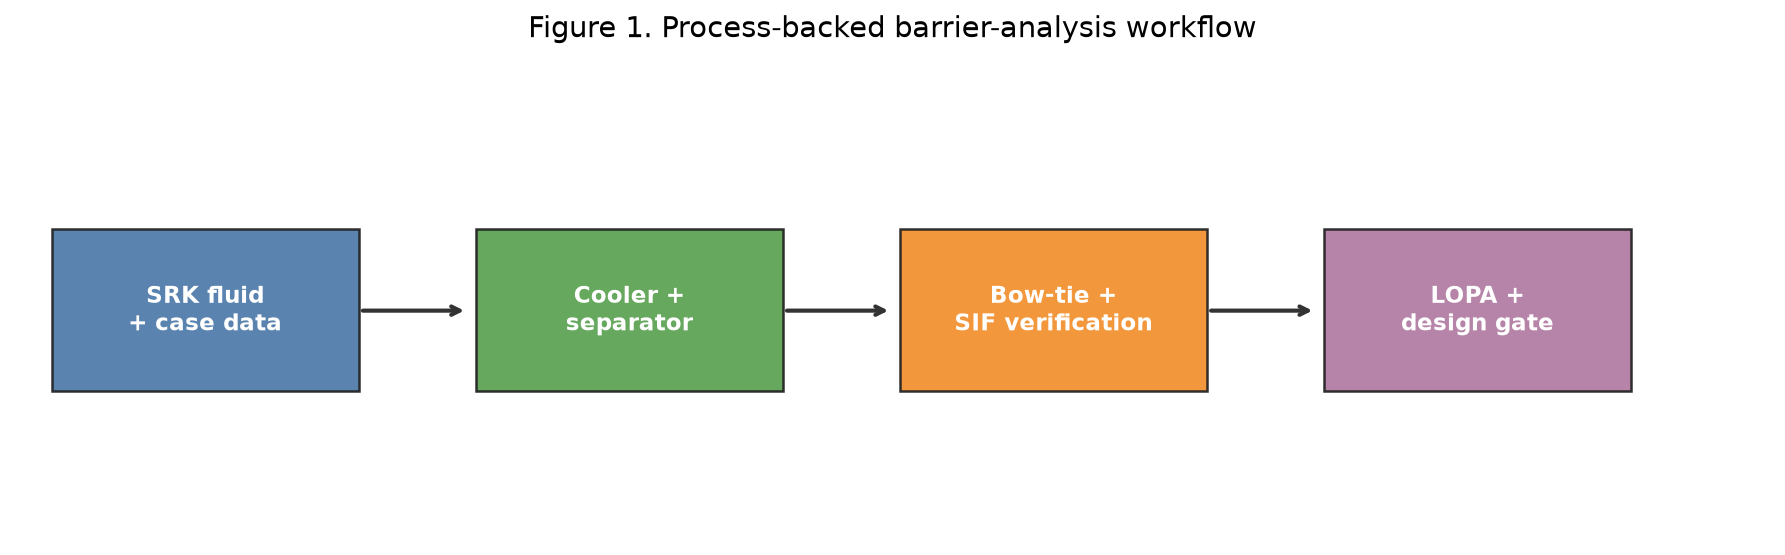

In [7]:
fig, ax = plt.subplots(figsize=(12.0, 3.8))
ax.set_xlim(0.0, 12.0)
ax.set_ylim(0.0, 4.0)
ax.axis("off")

steps = [
    (0.25, "SRK fluid\n+ case data", "#4C78A8"),
    (3.15, "Cooler +\nseparator", "#59A14F"),
    (6.05, "Bow-tie +\nSIF verification", "#F28E2B"),
    (8.95, "LOPA +\ndesign gate", "#B07AA1"),
]

for x_position, label, color in steps:
    box = plt.Rectangle(
        (x_position, 1.25),
        2.1,
        1.35,
        facecolor=color,
        edgecolor="#202020",
        linewidth=1.2,
        alpha=0.92,
    )
    ax.add_patch(box)
    ax.text(
        x_position + 1.05,
        1.92,
        label,
        color="white",
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
    )

for start_x in (2.35, 5.25, 8.15):
    ax.annotate(
        "",
        xy=(start_x + 0.75, 1.92),
        xytext=(start_x, 1.92),
        arrowprops={"arrowstyle": "->", "lw": 2.0, "color": "#333333"},
    )

ax.set_title(
    "Figure 1. Process-backed barrier-analysis workflow",
    fontsize=14,
    pad=12,
)
plt.tight_layout()
plt.show()

The workflow keeps thermodynamic evidence and risk assumptions distinct. NeqSim calculates
the fluid and process state; the initiating frequencies and PFDs remain documented
reliability inputs.

## Base process diagnostics

Gas density and separator gas inventory are consequence-screening evidence. The inventory
estimate assumes the stated vessel volume is entirely occupied by equilibrium gas; that is
conservative for this teaching case and is not a vessel-dynamics model.

In [8]:
separator_gas = base["separator"].getGasOutStream()
gas_density = separator_gas.getFluid().getDensity("kg/m3")
gas_inventory = gas_density * CASE["separator_volume_m3"]
pressure_margin = (
    CASE["separator_mawp_bara"] - separator_gas.getPressure("bara")
)

process_summary = pd.DataFrame(
    [
        ("Feed mass rate", feed_rate, "kg/h"),
        ("Gas product", gas_rate, "kg/h"),
        ("Liquid product", liquid_rate, "kg/h"),
        ("Gas density", gas_density, "kg/m³"),
        ("Screened gas inventory", gas_inventory, "kg"),
        ("MAWP pressure margin", pressure_margin, "bar"),
        ("Mass-balance residual", mass_residual, "kg/h"),
    ],
    columns=["quantity", "value", "unit"],
)
display(process_summary)

,quantity,value,unit
0,Feed mass rate,1.500000e+04,kg/h
1,Gas product,1.455977e+04,kg/h
2,Liquid product,4.402338e+02,kg/h
3,Gas density,7.937014e+01,kg/m³
4,Screened gas inventory,1.587403e+03,kg
5,MAWP pressure margin,2.500000e+01,bar
6,Mass-balance residual,-5.570655e-12,kg/h


## Figure 2 — phase-product result

The chart makes the small but non-zero condensate stream visible. That liquid is why the
cooler and separator cannot be replaced with a gas-only risk assumption.

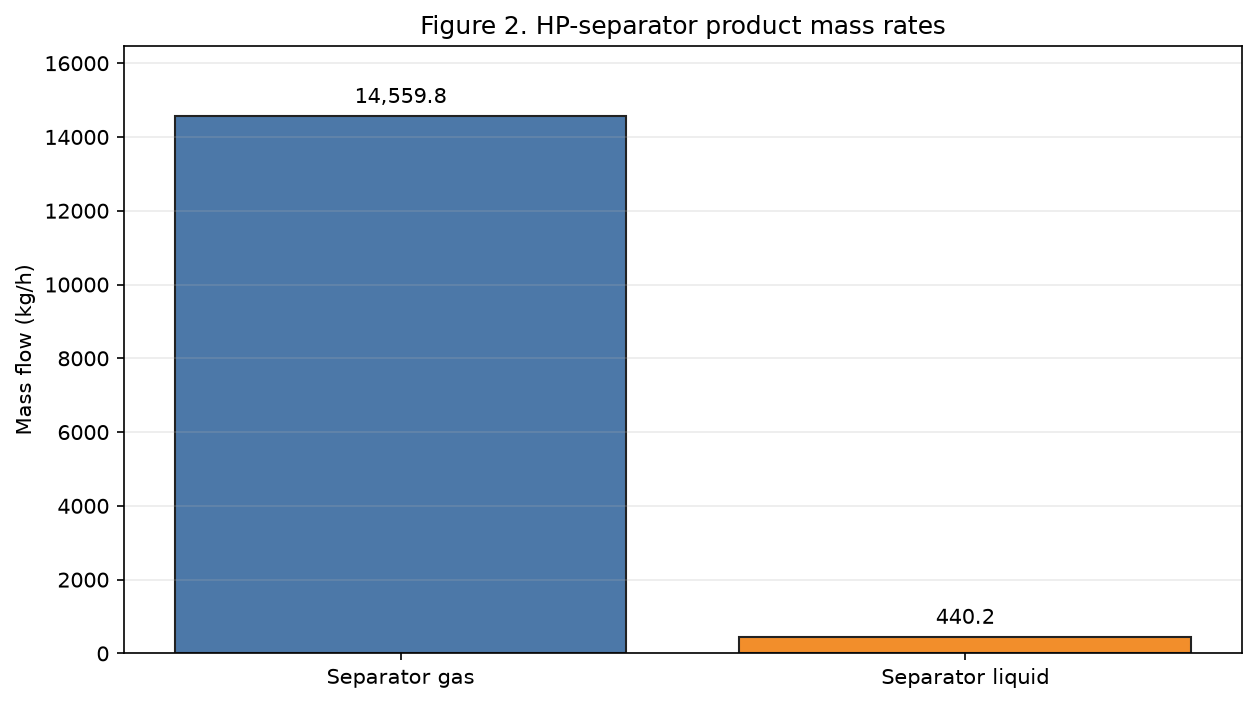

In [9]:
product_names = ["Separator gas", "Separator liquid"]
product_rates = [gas_rate, liquid_rate]
product_colors = ["#4C78A8", "#F28E2B"]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    product_names,
    product_rates,
    color=product_colors,
    edgecolor="#222222",
)
ax.bar_label(
    bars,
    labels=[f"{value:,.1f}" for value in product_rates],
    padding=4,
)
ax.set_ylabel("Mass flow (kg/h)")
ax.set_title("Figure 2. HP-separator product mass rates")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0.0, max(product_rates) * 1.13)
plt.tight_layout()
plt.show()

Cooling condenses approximately three percent of the feed mass. Both product streams are
retained in the mass audit, which closes to numerical precision.

## Configure a released NeqSim SIF

We use NeqSim's released 1oo2 screening equation at a one-year proof-test interval. The
demonstration claims SIL 3 because its calculated PFD lies in the SIL 3 low-demand band.
The failure rate is an assumption, not a library benchmark.

In [10]:
dangerous_undetected_rate_per_hr = 2.0e-6
proof_test_interval_hr = 8_760.0
sif_pfd = SafetyInstrumentedFunction.calculatePfd1oo2(
    dangerous_undetected_rate_per_hr,
    proof_test_interval_hr,
)

separator_sif = SafetyInstrumentedFunction(
    "SIF-101 HP separator inlet isolation",
    3,
    sif_pfd,
)
separator_sif.setCategory(SIFCategory.HIPPS)
separator_sif.setArchitecture("1oo2")
separator_sif.setTestIntervalHours(proof_test_interval_hr)
separator_sif.setDescription(
    "Independent PAHH logic closes the separator inlet valves"
)
separator_sif.setInitiatingEvent("HP separator overpressure")
separator_sif.setSafeState("Inlet isolated")
separator_sif.addProtectedEquipment("HP separator")

sif_verification = SILVerificationResult(separator_sif)
assert sif_verification.isSilAchieved()

## SIL verification result

`SILVerificationResult` checks the claimed SIL against PFD and reports architectural
warnings. A warning is retained rather than suppressed because the simplified model does
not demonstrate the diagnostic coverage needed for a project claim.

In [11]:
verification_summary = pd.DataFrame(
    [
        ("Claimed SIL", sif_verification.getClaimedSIL(), "-"),
        ("Achieved SIL", sif_verification.getAchievedSIL(), "-"),
        ("PFDavg", sif_verification.getPfdAverage(), "-"),
        ("Risk-reduction factor", separator_sif.getRiskReductionFactor(), "-"),
        ("Hardware fault tolerance", sif_verification.getHardwareFaultTolerance(), "-"),
        ("Diagnostic coverage", sif_verification.getDiagnosticCoverage(), "fraction"),
        ("Warnings", sif_verification.getWarnings().size(), "count"),
        ("Errors", sif_verification.getErrors().size(), "count"),
    ],
    columns=["quantity", "value", "unit"],
)
display(verification_summary)
print(str(sif_verification.toReport()))

SIL Verification Report
════════════════════════════════════════════════════════════

SIF: SIF-101 HP separator inlet isolation
Category: HIPPS
Architecture: 1oo2

SIL Assessment:
────────────────────────────────────────
  Claimed SIL:    3
  Achieved SIL:   3
  Target PFD:     1.00e-03
  Calculated PFD: 1.02e-04
  Status:         ✓ ACHIEVED

Architecture Assessment:
────────────────────────────────────────
  Hardware Fault Tolerance: 1
  Systematic Capability:    SC 3
  Diagnostic Coverage:      60%

Issues Found:
────────────────────────────────────────
  [WARNING] Diagnostic coverage (60%) may be insufficient for SIL 3
    → Implement enhanced diagnostics or online testing capabilities



,quantity,value,unit
0,Claimed SIL,3.000000,-
1,Achieved SIL,3.000000,-
2,PFDavg,0.000102,-
3,Risk-reduction factor,9773.566022,-
4,Hardware fault tolerance,1.000000,-
5,Diagnostic coverage,0.600000,fraction
6,Warnings,1.000000,count
7,Errors,0.000000,count


## Generate a bow-tie from the process topology

`BowTieAnalyzer.autoGenerateFromProcess()` detects that the flowsheet contains a separator
and creates the released overpressure threat and consequence library entries. Supplying the
SIF lets NeqSim assign it as a prevention barrier.

In [12]:
bowtie_analyzer = BowTieAnalyzer(
    "HP separator risk study",
    base["process"],
)
bowtie_analyzer.addAvailableSIF(separator_sif)
generated_bowties = bowtie_analyzer.autoGenerateFromProcess()

assert generated_bowties.size() == 1
separator_bowtie = generated_bowties.get(0)
sif_barrier = separator_bowtie.getPreventionBarriers().get(0)

for threat in separator_bowtie.getThreats():
    separator_bowtie.linkBarrierToThreat(
        threat.getId(),
        sif_barrier.getId(),
    )

relief_barrier = BowTieBarrier(
    "PSV-101",
    "Relief to a verified flare system",
    0.02,
)
relief_barrier.setBarrierType(BarrierType.MITIGATION)
relief_barrier.setOwner("Process safety")
relief_barrier.setVerificationStatus("Screening assumption")
separator_bowtie.addBarrier(relief_barrier)

for consequence in separator_bowtie.getConsequences():
    separator_bowtie.linkBarrierToConsequence(
        consequence.getId(),
        relief_barrier.getId(),
    )

bowtie_analyzer.calculateRisk()

## Figure 3 — native NeqSim bow-tie

This SVG is generated by `BowTieSvgExporter` from the live native model. Threats are on the
left, the separator overpressure top event is central, and consequences are on the right.
The PAHH SIF is preventive; PSV-to-flare is mitigative.

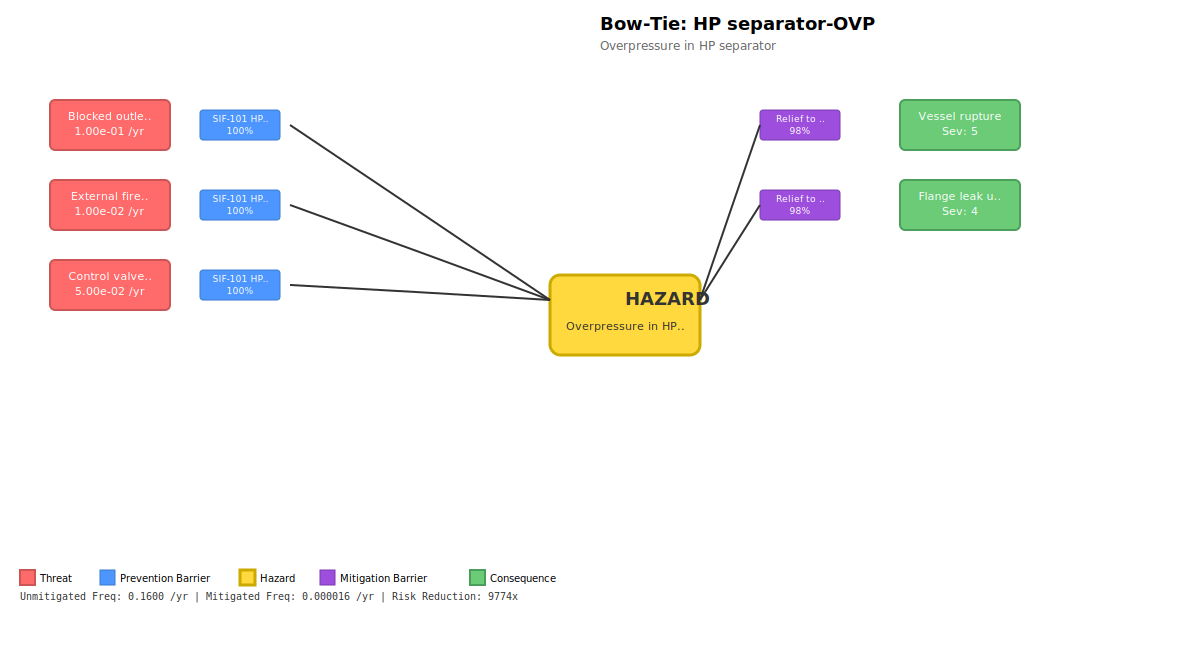

In [13]:
bowtie_svg = str(
    BowTieSvgExporter(
        separator_bowtie,
        1_200,
        650,
    ).export()
)
svg_root_start = bowtie_svg.find("<svg")
svg_root_end = bowtie_svg.find(">", svg_root_start)
bowtie_svg = (
    bowtie_svg[: svg_root_end + 1]
    + '<rect width="100%" height="100%" fill="white"/>'
    + bowtie_svg[svg_root_end + 1 :]
)
display(SVG(bowtie_svg))

The diagram has three library threats and two consequences. NeqSim's `calculateRisk()`
applies prevention barriers to the summed threat frequency and therefore reports a
mitigated **top-event** frequency. The separate consequence screen below then applies the
credited mitigation-barrier PFD. Neither value is a physical pressure trajectory.

In [14]:
screened_consequence_frequency = (
    separator_bowtie.getMitigatedFrequency()
    * relief_barrier.getPfd()
)

bowtie_summary = pd.DataFrame(
    [
        ("Threats", separator_bowtie.getThreats().size(), "count"),
        ("Consequences", separator_bowtie.getConsequences().size(), "count"),
        ("Prevention barriers", separator_bowtie.getPreventionBarriers().size(), "count"),
        ("Mitigation barriers", separator_bowtie.getMitigationBarriers().size(), "count"),
        (
            "Unmitigated frequency",
            separator_bowtie.getUnmitigatedFrequency(),
            "1/yr",
        ),
        (
            "Mitigated top-event frequency",
            separator_bowtie.getMitigatedFrequency(),
            "1/yr",
        ),
        (
            "Screened consequence frequency",
            screened_consequence_frequency,
            "1/yr",
        ),
        ("Total RRF", separator_bowtie.getTotalRRF(), "-"),
    ],
    columns=["quantity", "value", "unit"],
)
display(bowtie_summary)

assert separator_bowtie.getThreats().size() == 3
assert separator_bowtie.getConsequences().size() == 2
assert separator_bowtie.getMitigatedFrequency() < (
    separator_bowtie.getUnmitigatedFrequency()
)

,quantity,value,unit
0,Threats,3.000000e+00,count
1,Consequences,2.000000e+00,count
2,Prevention barriers,1.000000e+00,count
3,Mitigation barriers,1.000000e+00,count
4,Unmitigated frequency,1.600000e-01,1/yr
5,Mitigated top-event frequency,1.637069e-05,1/yr
6,Screened consequence frequency,3.274138e-07,1/yr
7,Total RRF,9.773566e+03,-


## Construct the LOPA

The blocked-outlet scenario uses an initiating frequency of 0.1 yr$^{-1}$, a BPCS pressure
control PFD of 0.1, an alarm-plus-operator PFD of 0.1, and the calculated SIF PFD. These
illustrative inputs must be replaced by approved project data. A target of
$10^{-5}$ yr$^{-1}$ is used only to demonstrate the decision logic.

In [15]:
def build_lopa(sif_probability):
    lopa = LOPAResult("Blocked outlet with continued feed")
    initiating_frequency = 0.1
    target_frequency = 1.0e-5
    lopa.setInitiatingEventFrequency(initiating_frequency)
    lopa.setTargetFrequency(target_frequency)

    frequency = initiating_frequency
    layer_inputs = [
        ("BPCS pressure control", 0.1),
        ("PAHH alarm and operator response", 0.1),
        ("SIF-101 inlet isolation", sif_probability),
    ]

    for layer_name, layer_pfd in layer_inputs:
        frequency_before = frequency
        frequency *= layer_pfd
        lopa.addLayer(
            layer_name,
            layer_pfd,
            frequency_before,
            frequency,
        )

    lopa.setMitigatedFrequency(frequency)
    return lopa


base_lopa = build_lopa(sif_pfd)
assert base_lopa.isTargetMet()
print(str(base_lopa.toVisualization()))

LOPA: Blocked outlet with continued feed
════════════════════════════════════════════════════════════

Initiating Event Frequency: 1.00e-01 /year

Protection Layers:
────────────────────────────────────────────────────────────
Layer                            PFD          Before           After
────────────────────────────────────────────────────────────
BPCS pressure control       1.00e-01        1.00e-01        1.00e-02
PAHH alarm and operator response   1.00e-01        1.00e-02        1.00e-03
SIF-101 inlet isolation     1.02e-04        1.00e-03        1.02e-07
────────────────────────────────────────────────────────────
TOTAL                        977357x                        1.02e-07

Target Frequency: 1.00e-05 /year
Status: ✓ TARGET MET



## Figure 4 — frequency reduction through the layers

The logarithmic axis is essential because each layer changes frequency by orders of
magnitude. The dashed line is the screening target.

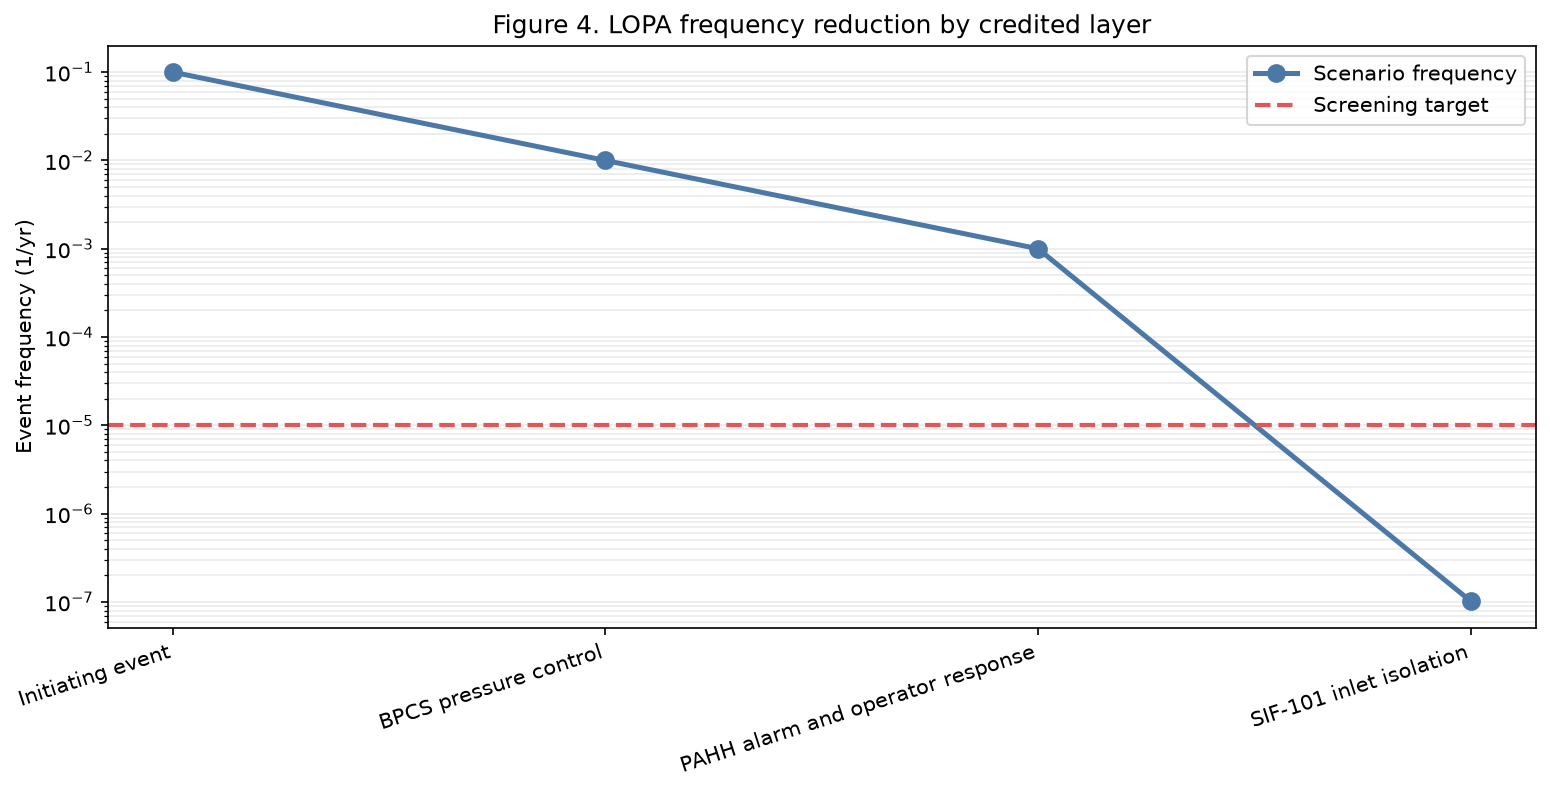

In [16]:
lopa_layers = list(base_lopa.getLayers())
waterfall_labels = ["Initiating event"] + [
    str(layer.getName()) for layer in lopa_layers
]
waterfall_frequencies = [
    base_lopa.getInitiatingEventFrequency()
] + [layer.getFrequencyAfter() for layer in lopa_layers]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
ax.plot(
    waterfall_labels,
    waterfall_frequencies,
    marker="o",
    linewidth=2.4,
    markersize=8,
    color="#4C78A8",
    label="Scenario frequency",
)
ax.axhline(
    base_lopa.getTargetFrequency(),
    color="#E15759",
    linestyle="--",
    linewidth=2.0,
    label="Screening target",
)
ax.set_yscale("log")
ax.set_ylabel("Event frequency (1/yr)")
ax.set_title("Figure 4. LOPA frequency reduction by credited layer")
ax.grid(axis="y", which="both", alpha=0.25)
ax.legend()
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()

The two non-SIS layers reduce the scenario to $10^{-3}$ yr$^{-1}$. The 1oo2 SIF then
reduces it below the illustrative target. This conclusion depends on independence and on
maintaining the assumed SIF PFD.

## Proof-test and architecture sensitivity

A longer proof-test interval increases dangerous-undetected exposure. We compare the
released 1oo1, 1oo2, and 2oo3 screening functions over six independent intervals and check
the 1oo1 formula analytically.

In [17]:
test_intervals_years = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0])
architecture_rows = []

for interval_years in test_intervals_years:
    interval_hours = interval_years * 8_760.0
    pfd_1oo1 = SafetyInstrumentedFunction.calculatePfd1oo1(
        dangerous_undetected_rate_per_hr,
        interval_hours,
    )
    pfd_1oo2 = SafetyInstrumentedFunction.calculatePfd1oo2(
        dangerous_undetected_rate_per_hr,
        interval_hours,
    )
    pfd_2oo3 = SafetyInstrumentedFunction.calculatePfd2oo3(
        dangerous_undetected_rate_per_hr,
        interval_hours,
    )
    independent_1oo1 = (
        dangerous_undetected_rate_per_hr * interval_hours / 2.0
    )

    assert abs(pfd_1oo1 - independent_1oo1) < 1.0e-15
    architecture_rows.extend(
        [
            (interval_years, "1oo1", pfd_1oo1),
            (interval_years, "1oo2", pfd_1oo2),
            (interval_years, "2oo3", pfd_2oo3),
        ]
    )

architecture_study = pd.DataFrame(
    architecture_rows,
    columns=["proof_test_interval_years", "architecture", "PFDavg"],
)
display(architecture_study)

,proof_test_interval_years,architecture,PFDavg
0,0.5,1oo1,0.004380
1,0.5,1oo2,0.000026
2,0.5,2oo3,0.000077
3,1.0,1oo1,0.008760
4,1.0,1oo2,0.000102
5,1.0,2oo3,0.000307
6,1.5,1oo1,0.013140
7,1.5,1oo2,0.000230
8,1.5,2oo3,0.000691
9,2.0,1oo1,0.017520


## Figure 5 — proof-test interval sensitivity

Lower PFD is better. The plot uses a logarithmic PFD axis and shows low-demand SIL bands as
visual screening guides. Architecture alone is not a complete verification because common
cause and component allocation are absent.

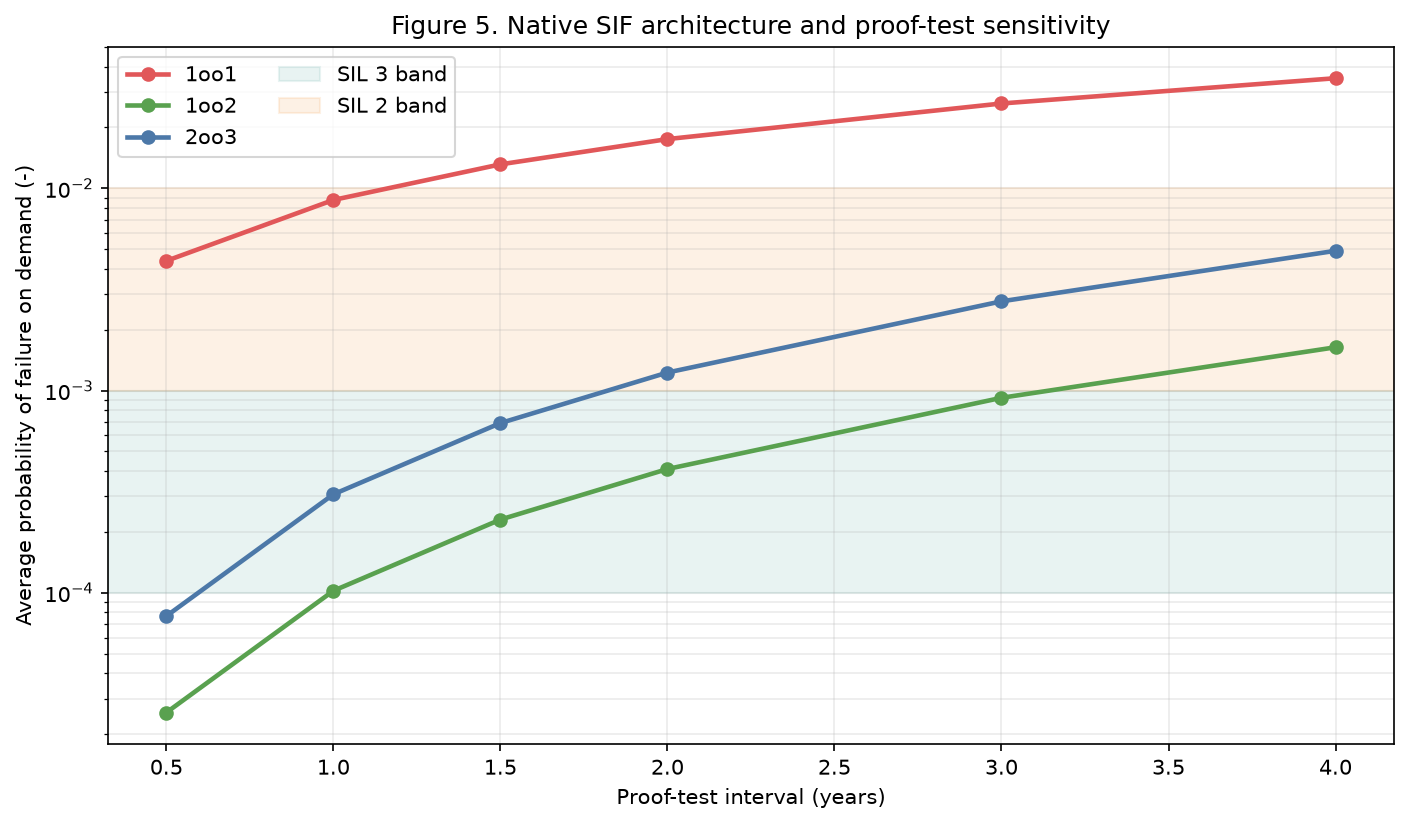

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
architecture_colors = {
    "1oo1": "#E15759",
    "1oo2": "#59A14F",
    "2oo3": "#4C78A8",
}

for architecture, group in architecture_study.groupby("architecture"):
    ax.plot(
        group["proof_test_interval_years"],
        group["PFDavg"],
        marker="o",
        linewidth=2.2,
        color=architecture_colors[architecture],
        label=architecture,
    )

ax.axhspan(1.0e-4, 1.0e-3, color="#76B7B2", alpha=0.16, label="SIL 3 band")
ax.axhspan(1.0e-3, 1.0e-2, color="#F28E2B", alpha=0.12, label="SIL 2 band")
ax.set_yscale("log")
ax.set_xlabel("Proof-test interval (years)")
ax.set_ylabel("Average probability of failure on demand (-)")
ax.set_title("Figure 5. Native SIF architecture and proof-test sensitivity")
ax.grid(which="both", alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

The 1oo2 screening model remains in the SIL 3 PFD band at one year, but reaches the SIL 2
band by four years. A real design should shorten the interval or improve the verified
subsystem model before claiming SIL 3.

## Practical application: operating cases plus safeguard health

The final workflow rebuilds the NeqSim process for three throughputs and combines each
solved gas rate with one- and four-year SIF cases. A gas-rate gate compares the separator
load with a stated relief-screening capacity; the risk gate compares LOPA frequency with
the stated target.

In [19]:
def evaluate_application(feed_flow_kg_per_hr, test_interval_years):
    case_data = dict(CASE)
    case_data["composition_mole_fraction"] = dict(
        CASE["composition_mole_fraction"]
    )
    case_data["feed_flow_kg_per_hr"] = feed_flow_kg_per_hr

    equipment = build_process(case_data)
    equipment["process"].run()

    scenario_gas_rate = (
        equipment["separator"].getGasOutStream().getFlowRate("kg/hr")
    )
    scenario_liquid_rate = (
        equipment["separator"].getLiquidOutStream().getFlowRate("kg/hr")
    )
    scenario_mass_residual = (
        feed_flow_kg_per_hr
        - scenario_gas_rate
        - scenario_liquid_rate
    )

    interval_hours = test_interval_years * 8_760.0
    scenario_pfd = SafetyInstrumentedFunction.calculatePfd1oo2(
        dangerous_undetected_rate_per_hr,
        interval_hours,
    )
    scenario_lopa = build_lopa(scenario_pfd)
    gas_rate_kg_per_s = scenario_gas_rate / 3_600.0

    return {
        "feed_flow_kg_per_hr": feed_flow_kg_per_hr,
        "test_interval_years": test_interval_years,
        "gas_rate_kg_per_s": gas_rate_kg_per_s,
        "liquid_rate_kg_per_hr": scenario_liquid_rate,
        "PFDavg": scenario_pfd,
        "residual_frequency_per_year": (
            scenario_lopa.getMitigatedFrequency()
        ),
        "risk_target_met": scenario_lopa.isTargetMet(),
        "relief_screening_gate_met": (
            gas_rate_kg_per_s
            <= CASE["relief_screening_capacity_kg_per_s"]
        ),
        "mass_residual_kg_per_hr": scenario_mass_residual,
    }


application_rows = []
for feed_flow in (10_000.0, 15_000.0, 20_000.0):
    for interval_years in (1.0, 4.0):
        application_rows.append(
            evaluate_application(
                feed_flow,
                interval_years,
            )
        )

application_study = pd.DataFrame(application_rows)
application_study["overall_screen_pass"] = (
    application_study["risk_target_met"]
    & application_study["relief_screening_gate_met"]
)
display(application_study)

,feed_flow_kg_per_hr,test_interval_years,gas_rate_kg_per_s,liquid_rate_kg_per_hr,PFDavg,residual_frequency_per_year,risk_target_met,relief_screening_gate_met,mass_residual_kg_per_hr,overall_screen_pass
0,10000.0,1.0,2.696253,293.489197,0.000102,1.023168e-07,True,True,0.000000e+00,True
1,10000.0,4.0,2.696253,293.489197,0.001637,1.637069e-06,True,True,0.000000e+00,True
2,15000.0,1.0,4.044380,440.233795,0.000102,1.023168e-07,True,True,-7.389644e-12,True
3,15000.0,4.0,4.044380,440.233795,0.001637,1.637069e-06,True,True,-7.389644e-12,True
4,20000.0,1.0,5.392506,586.978394,0.000102,1.023168e-07,True,False,0.000000e+00,False
5,20000.0,4.0,5.392506,586.978394,0.001637,1.637069e-06,True,False,0.000000e+00,False


## Figure 6 — integrated scenario screen

Marker shape identifies overall pass/fail, color shows residual frequency, and the dashed
line is the explicit gas-rate screening capacity. This separates an adequate LOPA result
from an overloaded relief design basis.

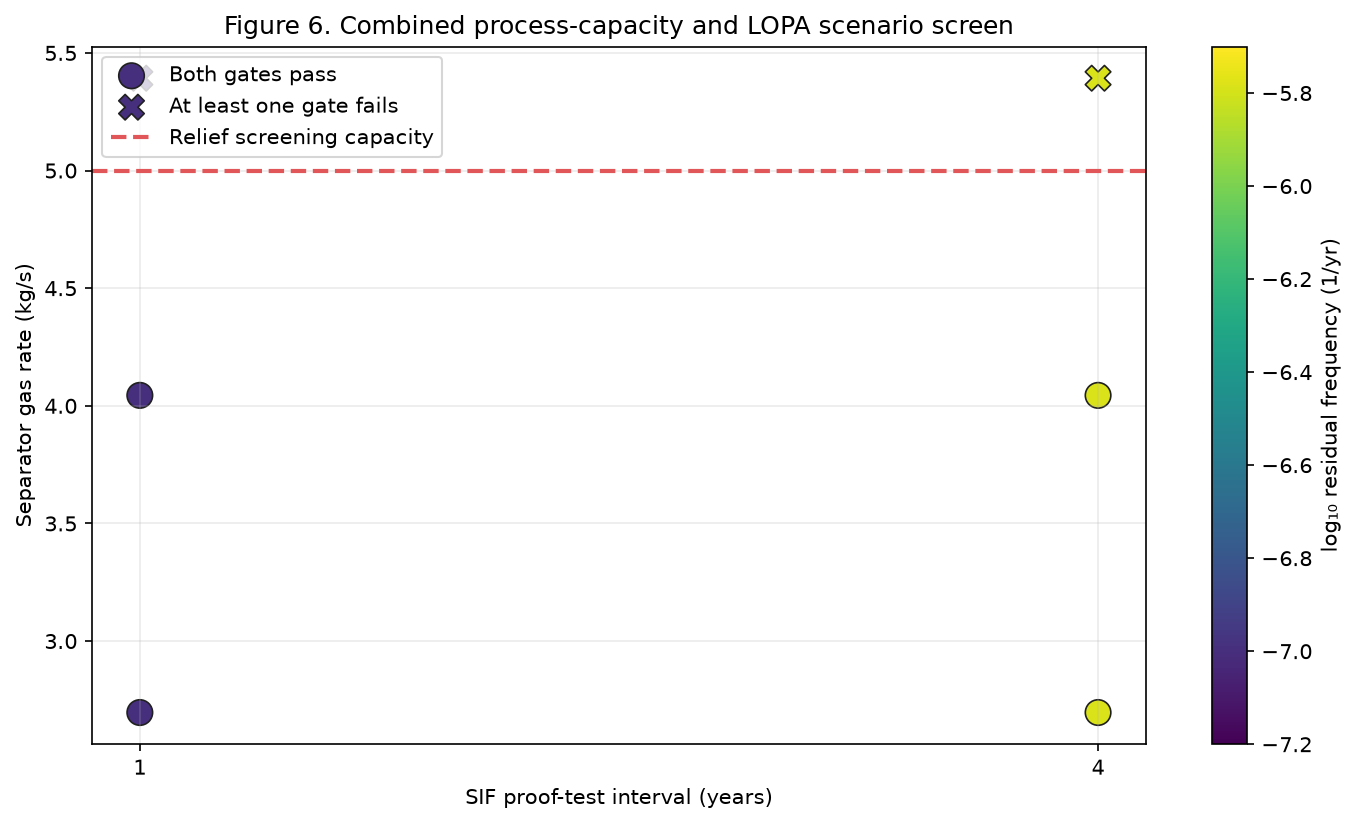

In [20]:
fig, ax = plt.subplots(figsize=(9.6, 5.6))

for passed, marker, label in [
    (True, "o", "Both gates pass"),
    (False, "X", "At least one gate fails"),
]:
    subset = application_study[
        application_study["overall_screen_pass"] == passed
    ]
    scatter = ax.scatter(
        subset["test_interval_years"],
        subset["gas_rate_kg_per_s"],
        c=np.log10(subset["residual_frequency_per_year"]),
        cmap="viridis",
        vmin=-7.2,
        vmax=-5.7,
        marker=marker,
        s=150,
        edgecolor="#202020",
        linewidth=0.8,
        label=label,
    )

ax.axhline(
    CASE["relief_screening_capacity_kg_per_s"],
    color="#E15759",
    linestyle="--",
    linewidth=2.0,
    label="Relief screening capacity",
)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("log₁₀ residual frequency (1/yr)")
ax.set_xlabel("SIF proof-test interval (years)")
ax.set_ylabel("Separator gas rate (kg/s)")
ax.set_title("Figure 6. Combined process-capacity and LOPA scenario screen")
ax.set_xticks([1.0, 4.0])
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The high-throughput case exceeds the stated gas-rate screening basis even when LOPA passes.
This is the practical distinction between **frequency reduction** and **physical capacity**:
neither result can substitute for the other.

## Validation checks

The final cell checks runtime completeness, topology discovery, conservation, native versus
analytical PFD, frequency multiplication, expected sensitivity, finite results, and both
passing and failing application cases.

In [21]:
all_numeric = application_study.select_dtypes(include=[np.number])
expected_lopa_frequency = (
    base_lopa.getInitiatingEventFrequency()
    * 0.1
    * 0.1
    * sif_pfd
)
one_year_pfd = architecture_study.query(
    "architecture == '1oo2' and proof_test_interval_years == 1.0"
)["PFDavg"].iloc[0]
four_year_pfd = architecture_study.query(
    "architecture == '1oo2' and proof_test_interval_years == 4.0"
)["PFDavg"].iloc[0]

checks = {
    "composition normalized": abs(composition_sum - 1.0) < 1.0e-12,
    "base mass balance closes": abs(mass_residual) < 1.0e-6,
    "gas and liquid products positive": gas_rate > liquid_rate > 0.0,
    "one separator bow-tie discovered": generated_bowties.size() == 1,
    "three native threats retained": separator_bowtie.getThreats().size() == 3,
    "two native consequences retained": (
        separator_bowtie.getConsequences().size() == 2
    ),
    "all threats linked to SIF barrier": all(
        threat.getLinkedBarrierIds().contains(sif_barrier.getId())
        for threat in separator_bowtie.getThreats()
    ),
    "all consequences linked to relief barrier": all(
        consequence.getLinkedBarrierIds().contains(
            relief_barrier.getId()
        )
        for consequence in separator_bowtie.getConsequences()
    ),
    "mitigation reduces screened consequence frequency": (
        screened_consequence_frequency
        < separator_bowtie.getMitigatedFrequency()
    ),
    "claimed SIL achieved": sif_verification.isSilAchieved(),
    "no SIL verification errors": not sif_verification.hasErrors(),
    "LOPA target met": base_lopa.isTargetMet(),
    "LOPA multiplication matches": abs(
        base_lopa.getMitigatedFrequency() - expected_lopa_frequency
    )
    < 1.0e-15,
    "longer test interval increases PFD": four_year_pfd > one_year_pfd,
    "all scenario results finite": np.isfinite(all_numeric.to_numpy()).all(),
    "all scenario mass balances close": (
        application_study["mass_residual_kg_per_hr"].abs().max()
        < 1.0e-6
    ),
    "study contains a passing case": application_study[
        "overall_screen_pass"
    ].any(),
    "study contains a failing case": (
        ~application_study["overall_screen_pass"]
    ).any(),
}

validation_table = pd.DataFrame(
    {
        "check": checks.keys(),
        "passed": checks.values(),
    }
)
display(validation_table)
assert all(checks.values())

print(
    "All validation checks passed. "
    f"Base residual frequency = "
    f"{base_lopa.getMitigatedFrequency():.3e} 1/yr."
)

All validation checks passed. Base residual frequency = 1.023e-07 1/yr.


,check,passed
0,composition normalized,True
1,base mass balance closes,True
2,gas and liquid products positive,True
3,one separator bow-tie discovered,True
4,three native threats retained,True
5,two native consequences retained,True
6,all threats linked to SIF barrier,True
7,all consequences linked to relief barrier,True
8,mitigation reduces screened consequence frequency,True
9,claimed SIL achieved,True


## Interpretation, limitations, and applicability

The base process closes its mass balance and gives a finite two-phase split. NeqSim
discovers the separator overpressure hazard, exports the bow-tie, verifies the simplified
SIF PFD, and reproduces the independent LOPA multiplication.

Use this workflow to structure early barrier reviews, test assumptions, compare proof-test
cases, and prepare auditable inputs for specialist review. Do not use it alone to approve a
SIF, size a PSV, claim compliance, or replace HAZOP/LOPA facilitation. Project work needs
approved initiating frequencies, common-cause treatment, demand and bypass histories,
verified relief and flare capacity, consequence modeling, and an approved safety
requirements specification.

## Troubleshooting

- If no bow-tie is discovered, verify that a named `Separator` or vessel is actually added
  to the `ProcessSystem` before `autoGenerateFromProcess()`.
- If no SIF barrier appears, set a category applicable to the hazard; `HIPPS` maps to
  separator overpressure in the released analyzer.
- If a LOPA result looks implausibly small, audit independence and unit basis before adding
  more layers.
- If repeated scenarios differ by run order, rebuild fresh fluid and equipment objects.
- Treat verification warnings as engineering actions, not cosmetic output.

## Summary and exercises

This notebook connected SRK phase behavior, streams, cooling, separation, process topology,
native bow-tie generation, SVG export, SIF PFD/SIL verification, LOPA, proof-test
sensitivity, and an end-to-end process-capacity decision.

Suggested exercises:

1. replace the illustrative initiating frequency with a documented project source;
2. add a second consequence-specific mitigation barrier and explain independence;
3. compare 1oo2 and 2oo3 only after adding an explicit common-cause sensitivity;
4. connect the gas-rate screen to a verified NeqSim PSV/flare calculation; and
5. serialize the bow-tie and LOPA maps for a governed engineering record.

## References

- [NeqSim risk framework](https://equinor.github.io/neqsim/risk/index.html)
- [NeqSim bow-tie analysis](https://equinor.github.io/neqsim/risk/bowtie-analysis.html)
- [NeqSim SIS integration](https://equinor.github.io/neqsim/risk/sis-integration.html)
- [NeqSim process package](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim risk API reference](https://equinor.github.io/neqsim/risk/api-reference)
- [IEC 61511 overview](https://www.iec.ch/functional-safety)

The NeqSim documentation describes the feature family. The executable code in this notebook
uses methods verified against the installed public NeqSim release.